# [실습]: 미션-데이터 분석 후 그래프로 시각화하기

## 1. 데이터 준비하기
- https://aihub.or.kr/
- AI 허브 데이터 검색:   국토환경 + 텍스트  > 수질측정및오염원 다운로드
- 압축풀고 > 원천데이터 > 1.물환경측정망 > 11.수질측정망 > vw_04_msr_wqmn.csv 
- vw_04_msr_wqmn.csv 

## 2. 데이터 전처리하기

### 2-1. 데이터 불러오기

In [1]:
import pandas as pd

#file = 'C:/python/dataAnalysis/data/vw_04_msr_wqmn.csv' 
file = 'data/vw_04_msr_wqmn.csv' 
df = pd.read_csv(file, encoding='CP949', engine='python')
print(type(df), df.size)
df.head(3)

<class 'pandas.core.frame.DataFrame'> 6491508


,년도,월,회차,수질측정망 명,수질측정망 코드,위도,경도,검사 일자,항목 코드,항목 명,값,항목 정제 여부
0,1989,1,1,경안천4,1016A50,37.3925,127.251638,19890109,1012,암모니아성질소(NH₃-N),NaN,NaN
1,1989,1,1,경안천4,1016A50,37.3925,127.251638,19890109,1013,질산성질소(NO₃-N),NaN,NaN
2,1989,1,1,경안천4,1016A50,37.3925,127.251638,19890109,1039,수소이온농도(pH),7.0,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540959 entries, 0 to 540958
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   년도        540959 non-null  int64  
 1   월         540959 non-null  int64  
 2   회차        540959 non-null  int64  
 3   수질측정망 명   540959 non-null  object 
 4   수질측정망 코드  540959 non-null  object 
 5   위도        540959 non-null  float64
 6   경도        540959 non-null  float64
 7   검사 일자     540959 non-null  int64  
 8   항목 코드     540959 non-null  int64  
 9   항목 명      540959 non-null  object 
 10  값         281313 non-null  float64
 11  항목 정제 여부  0 non-null       float64
dtypes: float64(4), int64(5), object(3)
memory usage: 49.5+ MB


### 2-2. 데이터 가공하기

#### 컬럼명에서 공백 제거하기 

In [5]:
df.columns = [name.replace(' ', '') for name in df.columns ]
df.head(3)

,년도,월,회차,수질측정망명,수질측정망코드,위도,경도,검사일자,항목코드,항목명,값,항목정제여부
0,1989,1,1,경안천4,1016A50,37.3925,127.251638,19890109,1012,암모니아성질소(NH₃-N),NaN,NaN
1,1989,1,1,경안천4,1016A50,37.3925,127.251638,19890109,1013,질산성질소(NO₃-N),NaN,NaN
2,1989,1,1,경안천4,1016A50,37.3925,127.251638,19890109,1039,수소이온농도(pH),7.0,NaN


#### Unique한 항목 명 출력하기

In [6]:
# set(df['항목명'])
df['항목명'].unique()

array(['암모니아성질소(NH₃-N)', '질산성질소(NO₃-N)', '수소이온농도(pH)', '화학적산소요구량(COD)',
       '전기전도도(EC)', '생물학적산소요구량(BOD)', '부유물질(SS)', '용존산소(DO)', '총질소(T-N)',
       '총인(T-P)', '유량', '수온', '클로로필-a(Chlorophyll-a)', '인산염(PO₄-P)',
       '용존총질소(DTN)', '용존총인(DTP)', '총유기탄소(TOC)'], dtype=object)

#### 특정 컬럼 추출하기: 생물학적산소요구량(BOD) & 화학적산소요구량(COD) 

In [30]:
# df.query(" 항목명 == '생물학적산소요구량(BOD)' ")
# df.iloc[ df.index[ df['항목명'] == '생물학적산소요구량(BOD)' ] ]
df.query(" 항목명 in ('생물학적산소요구량(BOD)', '화학적산소요구량(COD)') ")

,년도,월,회차,수질측정망명,수질측정망코드,위도,경도,검사일자,항목코드,항목명,값,항목정제여부
3,1989,1,1,경안천4,1016A50,37.392500,127.251638,19890109,1049,화학적산소요구량(COD),4.4,NaN
5,1989,1,1,경안천4,1016A50,37.392500,127.251638,19890109,1052,생물학적산소요구량(BOD),8.2,NaN
20,1989,1,1,성내천,1018A04,37.518152,127.107847,19890109,1049,화학적산소요구량(COD),7.0,NaN
22,1989,1,1,성내천,1018A04,37.518152,127.107847,19890109,1052,생물학적산소요구량(BOD),25.5,NaN
37,1989,1,1,탄천5,1018A22,37.510208,127.070622,19890109,1049,화학적산소요구량(COD),12.7,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
540911,1996,1,1,무주남대천,3003A10,36.004305,127.656805,19960121,1052,생물학적산소요구량(BOD),1.4,NaN
540926,1996,1,1,제원,3004A20,36.108027,127.569086,19960121,1049,화학적산소요구량(COD),0.8,NaN
540928,1996,1,1,제원,3004A20,36.108027,127.569086,19960121,1052,생물학적산소요구량(BOD),1.8,NaN
540943,1996,1,1,봉황천,3004A30,36.107638,127.553875,19960121,1049,화학적산소요구량(COD),3.1,NaN


#### 특정 컬럼 추출하기: 한 단어 이상 포함 데이터 추출
- df.query(" 컬러명.str.contains('검색어') ")

In [8]:
# 수질측정망명에 '안양천'이 들어간 데이터 추출하기
df.query(" 수질측정망명.str.contains('안양천') ")

,년도,월,회차,수질측정망명,수질측정망코드,위도,경도,검사일자,항목코드,항목명,값,항목정제여부
85,1989,1,1,안양천5,1018A86,37.547836,126.880941,19890131,1012,암모니아성질소(NH₃-N),NaN,NaN
86,1989,1,1,안양천5,1018A86,37.547836,126.880941,19890131,1013,질산성질소(NO₃-N),NaN,NaN
87,1989,1,1,안양천5,1018A86,37.547836,126.880941,19890131,1039,수소이온농도(pH),6.7,NaN
88,1989,1,1,안양천5,1018A86,37.547836,126.880941,19890131,1049,화학적산소요구량(COD),76.1,NaN
89,1989,1,1,안양천5,1018A86,37.547836,126.880941,19890131,1050,전기전도도(EC),NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
536549,1996,1,1,안양천5,1018A86,37.547836,126.880941,19960115,1063,클로로필-a(Chlorophyll-a),NaN,NaN
536550,1996,1,1,안양천5,1018A86,37.547836,126.880941,19960115,1065,인산염(PO₄-P),NaN,NaN
536551,1996,1,1,안양천5,1018A86,37.547836,126.880941,19960115,1066,용존총질소(DTN),NaN,NaN
536552,1996,1,1,안양천5,1018A86,37.547836,126.880941,19960115,1067,용존총인(DTP),NaN,NaN


#### 특정 컬럼 추출하기: 두 단어 이상 포함 데이터 추출
- df.query(" 컬러명.str.contains('검색어1|검색어2') ") 
- or조건(|)에 단어는 붙혀서 넣어야함

In [9]:
df.query(" 수질측정망명.str.contains('안양천|탄천') ")

,년도,월,회차,수질측정망명,수질측정망코드,위도,경도,검사일자,항목코드,항목명,값,항목정제여부
34,1989,1,1,탄천5,1018A22,37.510208,127.070622,19890109,1012,암모니아성질소(NH₃-N),NaN,NaN
35,1989,1,1,탄천5,1018A22,37.510208,127.070622,19890109,1013,질산성질소(NO₃-N),NaN,NaN
36,1989,1,1,탄천5,1018A22,37.510208,127.070622,19890109,1039,수소이온농도(pH),6.9,NaN
37,1989,1,1,탄천5,1018A22,37.510208,127.070622,19890109,1049,화학적산소요구량(COD),12.7,NaN
38,1989,1,1,탄천5,1018A22,37.510208,127.070622,19890109,1050,전기전도도(EC),NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
536957,1996,1,1,차탄천,1022A65,38.022858,127.054644,19960111,1063,클로로필-a(Chlorophyll-a),NaN,NaN
536958,1996,1,1,차탄천,1022A65,38.022858,127.054644,19960111,1065,인산염(PO₄-P),NaN,NaN
536959,1996,1,1,차탄천,1022A65,38.022858,127.054644,19960111,1066,용존총질소(DTN),NaN,NaN
536960,1996,1,1,차탄천,1022A65,38.022858,127.054644,19960111,1067,용존총인(DTP),NaN,NaN


#### 정렬하기: 한개의 컬럼 정렬
- df.sort_values(by=컬럼, ascending=True)

In [46]:
df.sort_values(by=df.columns[9], ascending=True)  # 항목명 으로 내림차순

,년도,월,회차,수질측정망명,수질측정망코드,위도,경도,검사일자,항목코드,항목명,값,항목정제여부
52264,1990,10,1,영천강,2019A20,35.163280,128.156422,19901024,1053,부유물질(SS),2.8,NaN
489436,1995,9,1,덕은리,1005A50,37.127005,127.800550,19950906,1053,부유물질(SS),19.3,NaN
259205,1993,11,1,영평천3,1022A35,38.020527,127.140250,19931125,1053,부유물질(SS),9.5,NaN
259222,1993,11,1,한탄강2,1022A37,38.036277,127.104333,19931125,1053,부유물질(SS),4.1,NaN
103043,1992,2,1,강경천,3013A80,36.159461,127.026844,19920219,1053,부유물질(SS),6.8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
417506,1995,2,1,병천천,3011A80,36.637263,127.350436,19950207,1049,화학적산소요구량(COD),2.2,NaN
246894,1993,9,1,대청댐3,3008B50,36.512000,127.506611,19930915,1049,화학적산소요구량(COD),2.5,NaN
48742,1990,9,1,예천,2003A50,36.524894,128.367302,19900910,1049,화학적산소요구량(COD),2.0,NaN
48708,1990,9,1,안동2,2003A10,36.555236,128.720300,19900906,1049,화학적산소요구량(COD),2.8,NaN


#### 정렬하기: 두개 이상 컬럼 정렬
- df.sort_values(by=[컬럼1,컬럼2], ascending=True)

In [47]:
# 년도, 월, 항목명으로 올림차순 정렬
df.sort_values(by=[df.columns[0], df.columns[1], df.columns[9]], ascending=True)

,년도,월,회차,수질측정망명,수질측정망코드,위도,경도,검사일자,항목코드,항목명,값,항목정제여부
6,1989,1,1,경안천4,1016A50,37.392500,127.251638,19890109,1053,부유물질(SS),3.5,NaN
23,1989,1,1,성내천,1018A04,37.518152,127.107847,19890109,1053,부유물질(SS),19.0,NaN
40,1989,1,1,탄천5,1018A22,37.510208,127.070622,19890109,1053,부유물질(SS),45.0,NaN
57,1989,1,1,중랑천1,1018A28,37.734811,127.055347,19890110,1053,부유물질(SS),23.0,NaN
74,1989,1,1,중랑천4,1018A48,37.547711,127.047702,19890110,1053,부유물질(SS),29.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
540875,1996,1,1,산호천,2504A27,35.227622,128.585594,19960112,1049,화학적산소요구량(COD),24.3,NaN
540892,1996,1,1,용포,3002A50,35.990694,127.616916,19960122,1049,화학적산소요구량(COD),1.3,NaN
540909,1996,1,1,무주남대천,3003A10,36.004305,127.656805,19960121,1049,화학적산소요구량(COD),1.0,NaN
540926,1996,1,1,제원,3004A20,36.108027,127.569086,19960121,1049,화학적산소요구량(COD),0.8,NaN


### [Target]
- 데이터: 수질측정망명 =='안양천1' &  항목명 in ('생물학적산소요구량(BOD)', '화학적산소요구량(COD)') 
- 정렬:  df.sort_values(by=[년도,월,항목명], ascending=True)

In [10]:
df_ = df.query("수질측정망명 =='안양천1' and 항목명 in ('생물학적산소요구량(BOD)', '화학적산소요구량(COD)') ")
df_.sort_values(by=[df_.columns[0], df_.columns[1], df_.columns[9]], ascending=True)

df_

,년도,월,회차,수질측정망명,수질측정망코드,위도,경도,검사일자,항목코드,항목명,값,항목정제여부
104400,1992,3,1,안양천1,1018A60,37.363302,126.955883,19920317,1049,화학적산소요구량(COD),73.0,NaN
104402,1992,3,1,안양천1,1018A60,37.363302,126.955883,19920317,1052,생물학적산소요구량(BOD),100.6,NaN
110979,1992,4,1,안양천1,1018A60,37.363302,126.955883,19920416,1049,화학적산소요구량(COD),88.7,NaN
110981,1992,4,1,안양천1,1018A60,37.363302,126.955883,19920416,1052,생물학적산소요구량(BOD),125.2,NaN
118646,1992,5,1,안양천1,1018A60,37.363302,126.955883,19920526,1049,화학적산소요구량(COD),36.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
514374,1995,11,1,안양천1,1018A60,37.363302,126.955883,19951115,1052,생물학적산소요구량(BOD),46.7,NaN
525575,1995,12,1,안양천1,1018A60,37.363302,126.955883,19951211,1049,화학적산소요구량(COD),39.8,NaN
525577,1995,12,1,안양천1,1018A60,37.363302,126.955883,19951211,1052,생물학적산소요구량(BOD),92.1,NaN
536438,1996,1,1,안양천1,1018A60,37.363302,126.955883,19960115,1049,화학적산소요구량(COD),63.8,NaN


#### 년월  컬럼 추가

In [98]:
# 년도, 월은 데이터 타입 확인하기
df_.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 94 entries, 104400 to 536440
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   년도       94 non-null     int64  
 1   월        94 non-null     int64  
 2   회차       94 non-null     int64  
 3   수질측정망명   94 non-null     object 
 4   수질측정망코드  94 non-null     object 
 5   위도       94 non-null     float64
 6   경도       94 non-null     float64
 7   검사일자     94 non-null     int64  
 8   항목코드     94 non-null     int64  
 9   항목명      94 non-null     object 
 10  값        94 non-null     float64
 11  항목정제여부   0 non-null      float64
dtypes: float64(4), int64(5), object(3)
memory usage: 9.5+ KB


In [101]:
# df_.drop('년월', axis=1, inplace=True)

In [11]:
# 1. 년도, 월은 숫자 타입 --> 문자열로 변환 
# 2. + 연산자 이용 --> 년도-월
#df.drop('년월', axis=1, inplace=True)
df_['년도'].apply(str)
df_['월_'] = df_['월'].astype('str').str.zfill(2) # 앞에 0으로 채우기
df_['년월'] = df_['년도'].apply(str) +'-'+ df_['월'].astype('str').str.zfill(2)

df_

c:\python\python38\lib\site-packages\pandas\core\frame.py:3607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._set_item(key, value)


,년도,월,회차,수질측정망명,수질측정망코드,위도,경도,검사일자,항목코드,항목명,값,항목정제여부,월_,년월
104400,1992,3,1,안양천1,1018A60,37.363302,126.955883,19920317,1049,화학적산소요구량(COD),73.0,NaN,03,1992-03
104402,1992,3,1,안양천1,1018A60,37.363302,126.955883,19920317,1052,생물학적산소요구량(BOD),100.6,NaN,03,1992-03
110979,1992,4,1,안양천1,1018A60,37.363302,126.955883,19920416,1049,화학적산소요구량(COD),88.7,NaN,04,1992-04
110981,1992,4,1,안양천1,1018A60,37.363302,126.955883,19920416,1052,생물학적산소요구량(BOD),125.2,NaN,04,1992-04
118646,1992,5,1,안양천1,1018A60,37.363302,126.955883,19920526,1049,화학적산소요구량(COD),36.3,NaN,05,1992-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514374,1995,11,1,안양천1,1018A60,37.363302,126.955883,19951115,1052,생물학적산소요구량(BOD),46.7,NaN,11,1995-11
525575,1995,12,1,안양천1,1018A60,37.363302,126.955883,19951211,1049,화학적산소요구량(COD),39.8,NaN,12,1995-12
525577,1995,12,1,안양천1,1018A60,37.363302,126.955883,19951211,1052,생물학적산소요구량(BOD),92.1,NaN,12,1995-12
536438,1996,1,1,안양천1,1018A60,37.363302,126.955883,19960115,1049,화학적산소요구량(COD),63.8,NaN,01,1996-01


### 2-3. 데이터 시각화하기
- 안양천1의 '생물학적산소요구량(BOD)'과 '화학적산소요구량(COD)' 선그래프로 나타내기
- data1 : '생물학적산소요구량(BOD)'
- data2 : '화학적산소요구량(COD)' 

#### X축, Y축 데이터
- data1 : '생물학적산소요구량(BOD)'
- data2 : '화학적산소요구량(COD)' 

In [109]:
tmp   = df_.query(" 항목명 == '생물학적산소요구량(BOD)' ")
X1 = tmp['년월']
Y1 = tmp['값']
tmp   = df_.query(" 항목명 == '화학적산소요구량(COD)' ")
X2 = tmp['년월']
Y2 = tmp['값']

Y1

104402    100.6
110981    125.2
118648     61.3
125227     84.1
133149    104.5
139728     20.0
147463     10.5
154110     10.0
161896     32.6
168050     42.0
174646     40.5
182857     37.5
191391     85.1
199755     45.3
208272     92.5
216789     14.3
225459      7.7
234010     44.7
242357     39.9
250670     72.8
258932     52.0
267228     54.4
276850    133.0
286744    118.0
296825     73.8
307229     62.2
317463     39.3
327612     92.0
338237     40.8
348811     44.4
359249     24.5
369585     44.7
380312     50.2
390597     57.8
401086     54.9
411966     85.7
423084    102.1
434423     58.9
445728     61.5
457101    112.4
468338     14.5
479881     25.0
491254     28.8
502916     79.6
514374     46.7
525577     92.1
536440    103.9
Name: 값, dtype: float64

#### 선그래프 그리기

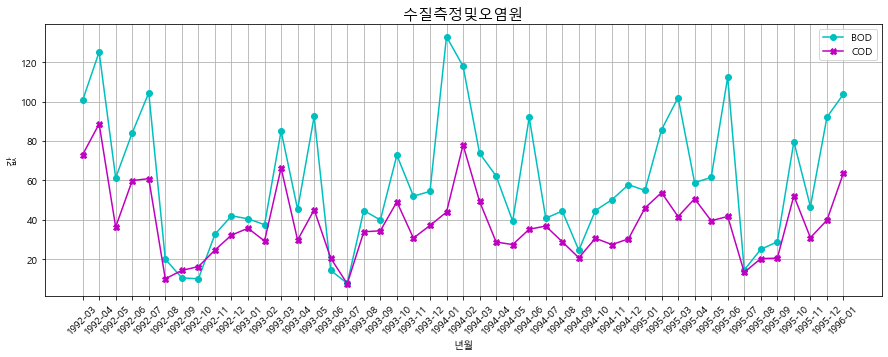

In [113]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

plt.figure(figsize=(15,5)) # 그래프 크기
plt.plot(X1, Y1, 'o', linestyle='solid', c='c', label='BOD')     #선 그래프
plt.plot(X2, Y2, 'X', linestyle='solid', c='m', label='COD')     #선 그래프
plt.title("수질측정및오염원", fontsize=15) #제목
plt.xlabel('년월')        # x축 레이블
plt.ylabel('값')          # y축 레이블             
plt.legend()             #범례,기본 위치 : loc='upper left'
plt.xticks(rotation=45)  # x축 레이블 기울이기
plt.grid()               # 격자 표시
plt.show()